### What is the price distribution of menu items?

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



In [2]:
conn=duckdb.connect('my_database.duckdb')

In [3]:
price_delivero=conn.execute(
    """
        SELECT price 
        FROM deliveroo_menu_items
    """
).df()
price_takeaway=conn.execute(
    """
        SELECT price 
        FROM takeaway_menuItems
    """
).df()
price_ubereats=conn.execute(
    """
        SELECT price 
        FROM ubereats_menu_items
    """
).df()


In [ ]:
price_delivero["price"] = pd.to_numeric(price_delivero["price"], errors="coerce")
price_takeaway["price"] = pd.to_numeric(price_takeaway["price"], errors="coerce")
price_ubereats["price"] = pd.to_numeric(price_ubereats["price"], errors="coerce")

price_ubereats["price"] = price_ubereats["price"] / 100


In [5]:
print(price_delivero.describe())
print('*'*50)
print(price_takeaway.describe())
print('*'*50)
print(price_ubereats.describe())

               price
count  292038.000000
mean        6.056445
std         9.972373
min       -12.500000
25%         1.000000
50%         3.500000
75%         8.500000
max      2000.000000
**************************************************
               price
count  403013.000000
mean        9.973233
std         8.384140
min         0.000000
25%         4.000000
50%         9.000000
75%        13.950000
max       150.000000
**************************************************
               price
count  204338.000000
mean        9.151735
std         8.549264
min         0.000000
25%         3.500000
50%         7.000000
75%        12.950000
max       230.000000


In [6]:

price_delivero_filter=price_delivero[price_delivero['price']<price_delivero["price"].quantile(0.95)]
price_delivero_filter=price_delivero_filter[price_delivero_filter['price']>=0]

price_takeaway_filter=price_takeaway[price_takeaway['price']<price_takeaway["price"].quantile(0.95)]

price_ubereats_filter = price_ubereats[price_ubereats['price'] < price_ubereats["price"].quantile(0.95)]


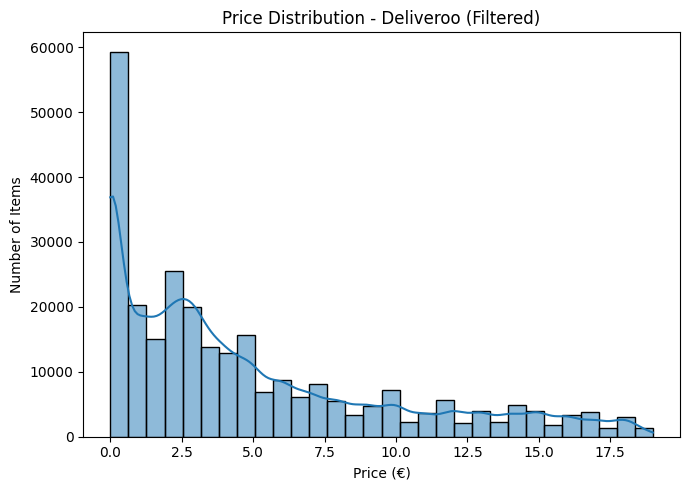

In [ ]:
# Plot for Deliveroo
plt.figure(figsize=(7, 5))
sns.histplot(data=price_delivero_filter, x="price", bins=30, kde=True)
plt.title("Price Distribution - Deliveroo (Filtered)")
plt.xlabel("Price (€)")
plt.ylabel("Number of Items")
plt.tight_layout()
plt.show()


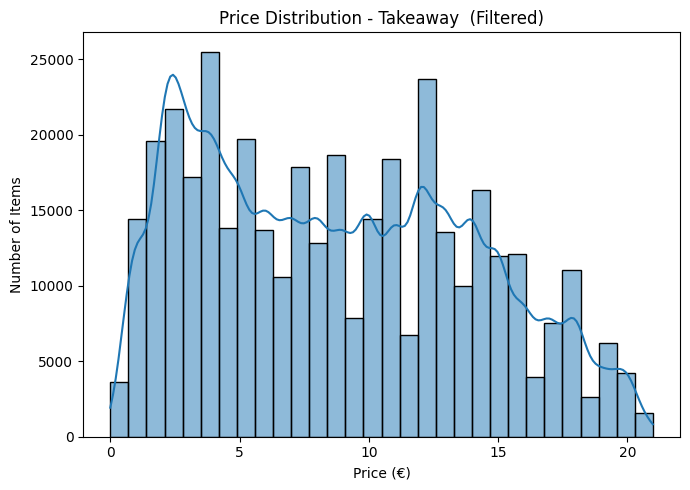

In [ ]:
# Plot for Takeaway
plt.figure(figsize=(7, 5))
sns.histplot(data=price_takeaway_filter, x="price", bins=30, kde=True)
plt.title("Price Distribution - Takeaway  (Filtered)")
plt.xlabel("Price (€)")
plt.ylabel("Number of Items")
plt.tight_layout()
plt.show()


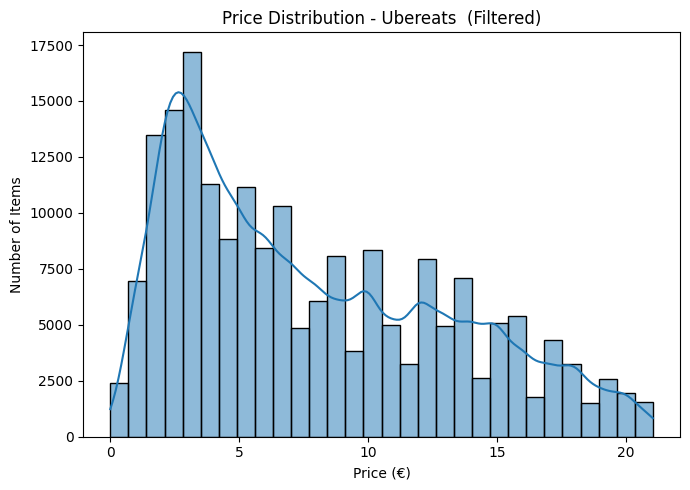

In [ ]:
# Plot for Ubereats
plt.figure(figsize=(7, 5))
sns.histplot(data=price_ubereats_filter, x="price", bins=30, kde=True)
plt.title("Price Distribution - Ubereats  (Filtered)")
plt.xlabel("Price (€)")
plt.ylabel("Number of Items")
plt.tight_layout()
plt.show()

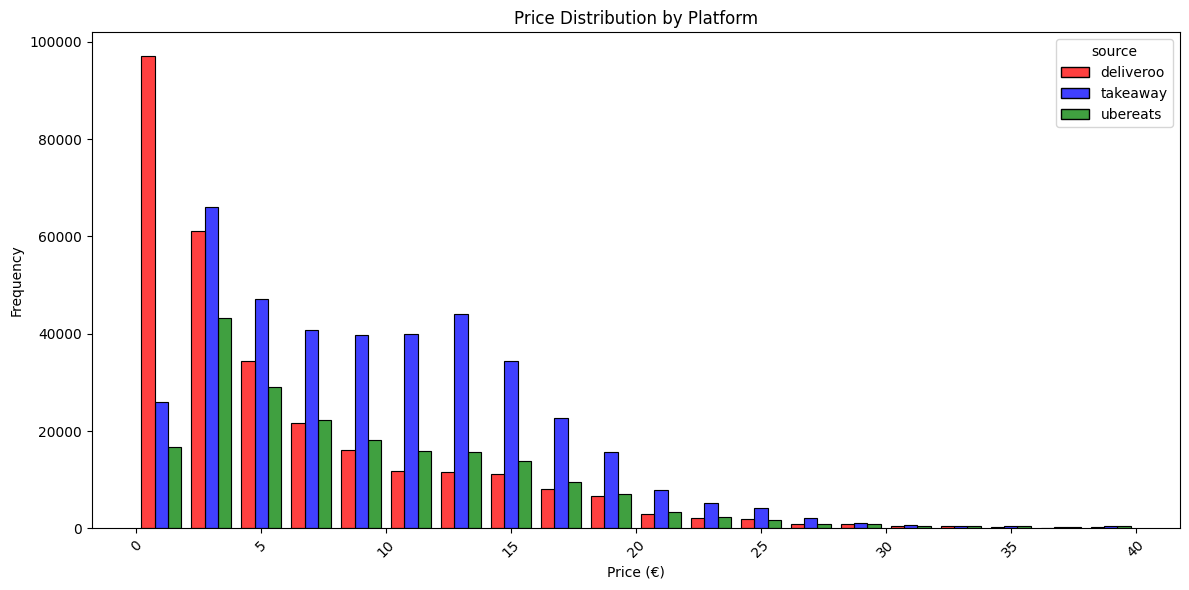

In [ ]:
df = conn.execute("""
    SELECT 'deliveroo' AS source, price FROM deliveroo_menu_items
    UNION ALL
    SELECT 'takeaway' AS source, price FROM takeaway_menuItems
    UNION ALL
    SELECT 'ubereats' AS source, CAST(price  AS FLOAT)/ 100 AS price FROM ubereats_menu_items
""").fetchdf()


df["price"] = pd.to_numeric(df["price"], errors="coerce")


df=df[df['price'] >=0]
df = df.dropna(subset=["price"])



n_bins = 20
bins = np.linspace(0, 40, n_bins + 1)


plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="price",
    hue="source",
    bins=bins,
    multiple="dodge",     
    shrink=0.8,           
    palette={
        "deliveroo": "red",
        "ubereats": "green",
        "takeaway": "blue"
    }
)


plt.title("Price Distribution by Platform")
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
conn.close()